# Complete Single-Stage Run: Midpoint Geometry

In [24]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

sys.path.insert(0, '../../..')
sys.path.insert(0, '../..')
sys.path.insert(0, '.')

plt.style.use('../../../configurations/style.mplstyle')
datafiles           = Path('../../../datafiles')
baseline_filenames  = "../Output_files/baseline_flat_midpoint_alpha"
possible_alpha      = ["A0.5", "A1.0", "A3.0", "A5.0"]
baseline_paths      = {a : Path(f"{baseline_filenames}_{a}/emcee.h5") for a in possible_alpha}
for value in baseline_paths.values(): assert value.is_file(), f"File {value} does not exist."

from mcmc_runner import run_pop
from src.top_hat.geometric_eff import geometric_efficiency_flat_midpoint

print('Imports complete.')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Imports complete.


In [25]:
import emcee
fixed_params = {}
for alpha in possible_alpha:
    #test_backend    = baseline_paths["A5.0"]
    test_backend        = baseline_paths.get(alpha)
    samples             = emcee.backends.HDFBackend(test_backend).get_chain(flat=True, discard=3000, thin = 10)
    mu_e                = samples[:, 2]
    sigma_e             = samples[:, 3]
    e_vals, s_vals      = np.percentile(mu_e, [50, 5, 95]), np.percentile(sigma_e, [50, 5, 95])
    med_e, e_05, e_95   = e_vals
    med_s, s_05, s_95   = s_vals
    #print(f"Alpha: {alpha} | L_mu_E: {med_e:.3f} [{e_05:.3f}, {e_95:.3f}] | sigma_E: {med_s:.3f} [{s_05:.3f}, {s_95:.3f}]")
    A_index = samples[:, 0]
    log_values = emcee.backends.HDFBackend(test_backend).get_log_prob(flat=True, discard=3000, thin = 10)
    #maximum_log_value = np.max(log_values)
    #only take values with A < 3
    maximum_log_value = np.max(log_values[A_index < 3])
    max_indices = np.where(log_values == maximum_log_value)[0]
    max_e = mu_e[max_indices][0]
    
    max_s = sigma_e[max_indices][0]
    max_A = A_index[max_indices][0]
    print(f"Maximum log-probability: {maximum_log_value:.2f} at A={max_A:.2f}, L_mu_E={max_e:.2f}, sigma_E={max_s:.2f}")
    fixed_params[alpha] = {"L_mu_E": max_e, "sigma_E": max_s, "A_index": max_A}

Maximum log-probability: -4.18 at A=3.00, L_mu_E=3.35, sigma_E=0.37
Maximum log-probability: -3.92 at A=2.74, L_mu_E=3.32, sigma_E=0.31
Maximum log-probability: -4.38 at A=2.77, L_mu_E=3.31, sigma_E=0.34
Maximum log-probability: -4.15 at A=2.96, L_mu_E=3.40, sigma_E=0.42


Using redshift model: samples_fiducial_delayed_A0.5_BNSs_0.dat with 60187 BNSs.
Computed total merger rate: 60477.4 yr^-1 (local R_0 = 22.7 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 18332.3 yr^-1 (local R_0 = 3.8 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut / A0.5
  BHNSs local rate R_0 = 3.8 Gpc^-3 yr^-1
  BHNSs total rate     = 18332 yr^-1
  1-year z sample size = 18332
Loading existing directory  : Output_files/midpoint_complete_alpha_A0.5


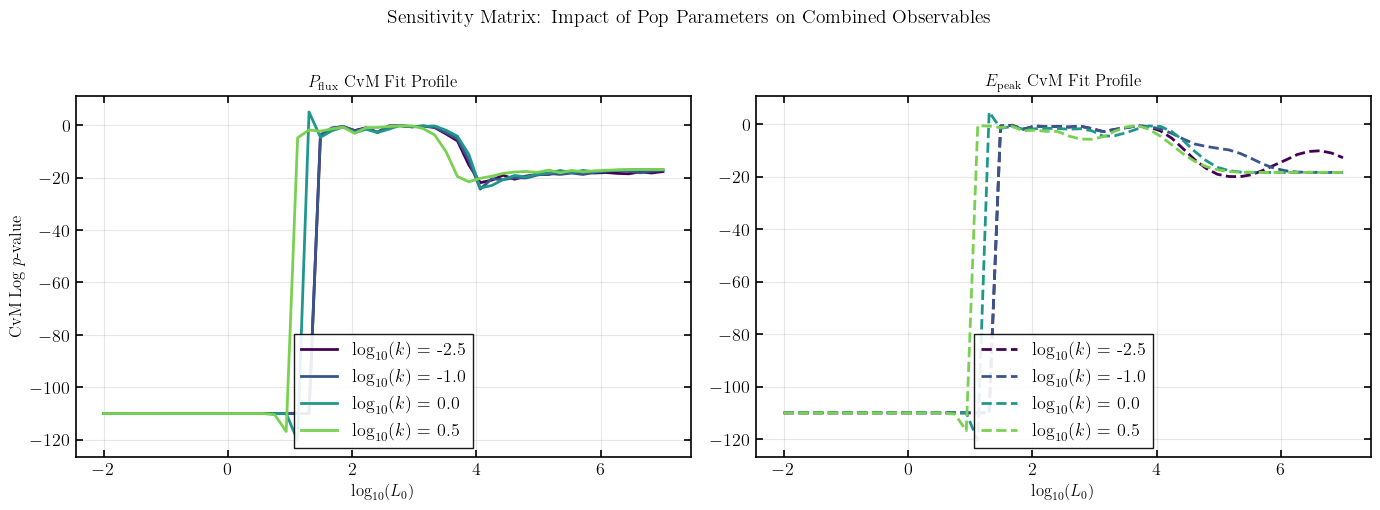

Already completed this run


0it [00:00, ?it/s]


Using redshift model: samples_fiducial_delayed_A1.0_BNSs_0.dat with 342071 BNSs.
Computed total merger rate: 343741.1 yr^-1 (local R_0 = 107.4 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 11117.2 yr^-1 (local R_0 = 2.3 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut / A1.0
  BHNSs local rate R_0 = 2.3 Gpc^-3 yr^-1
  BHNSs total rate     = 11117 yr^-1
  1-year z sample size = 11117
Loading existing directory  : Output_files/midpoint_complete_alpha_A1.0


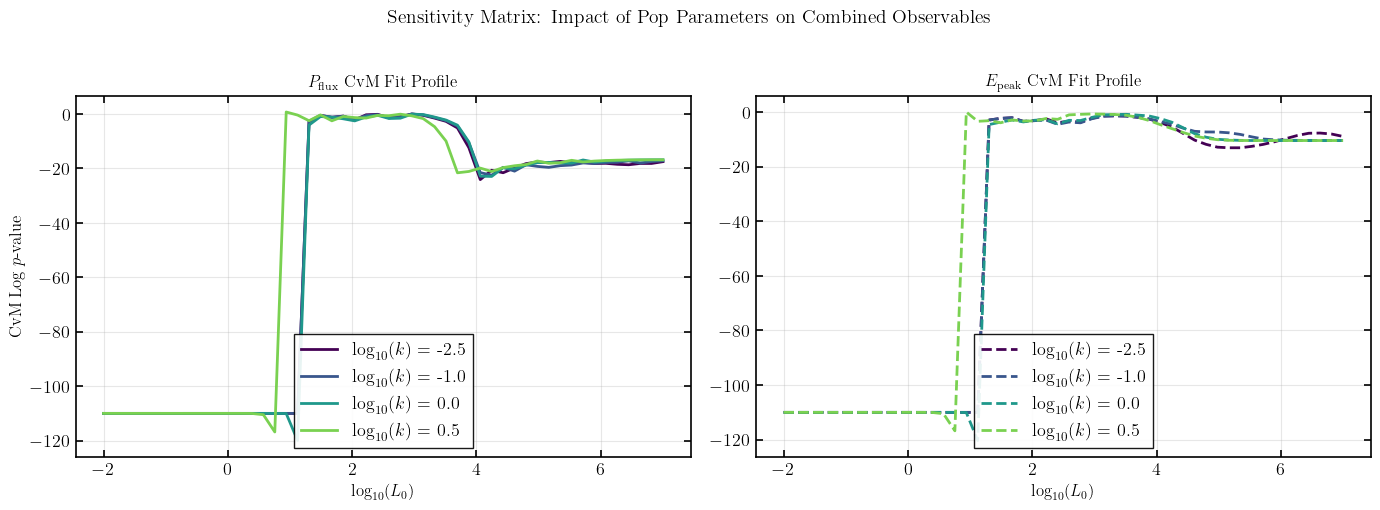

Continuing from iteration 69370


  0%|          | 50/130630 [00:02<1:51:51, 19.46it/s]/mnt/c/Users/Ludovico/Downloads/MAGGPY/NSBH/Baseline/k_prop_analytical/../../../src/top_hat/montecarlo.py:151: RuntimeWarning: invalid value encountered in log
  return -mu + k * np.log(mu) - sc.gammaln(k + 1)
100%|██████████| 130630/130630 [1:55:45<00:00, 18.81it/s] 


Using redshift model: samples_fiducial_delayed_A3.0_BNSs_0.dat with 358417 BNSs.
Computed total merger rate: 360097.8 yr^-1 (local R_0 = 178.9 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 4936.9 yr^-1 (local R_0 = 1.2 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut / A3.0
  BHNSs local rate R_0 = 1.2 Gpc^-3 yr^-1
  BHNSs total rate     = 4937 yr^-1
  1-year z sample size = 4936
Loading existing directory  : Output_files/midpoint_complete_alpha_A3.0


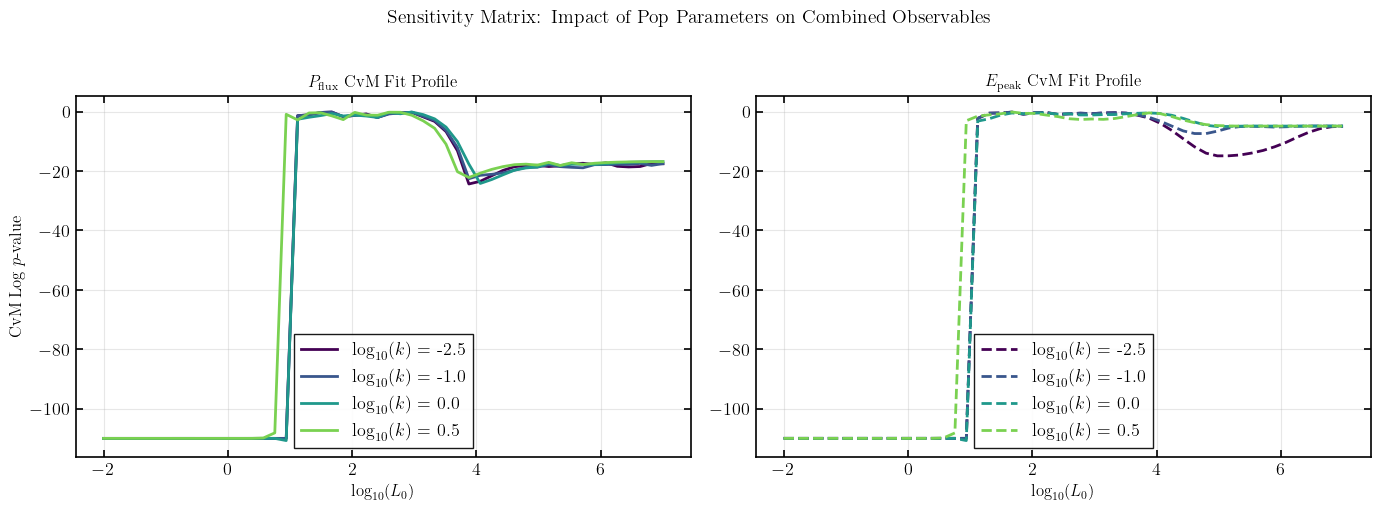

Starting new run from starting point


  0%|          | 0/200000 [00:00<?, ?it/s]/home/ludo/.local/lib/python3.10/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
  5%|▍         | 9151/200000 [07:59<2:48:48, 18.84it/s]/mnt/c/Users/Ludovico/Downloads/MAGGPY/NSBH/Baseline/k_prop_analytical/../../../src/top_hat/montecarlo.py:151: RuntimeWarning: invalid value encountered in log
  return -mu + k * np.log(mu) - sc.gammaln(k + 1)
100%|██████████| 200000/200000 [2:55:01<00:00, 19.04it/s]  


Using redshift model: samples_fiducial_delayed_A5.0_BNSs_0.dat with 136203 BNSs.
Computed total merger rate: 136874.3 yr^-1 (local R_0 = 127.8 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 4095.2 yr^-1 (local R_0 = 1.0 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut / A5.0
  BHNSs local rate R_0 = 1.0 Gpc^-3 yr^-1
  BHNSs total rate     = 4095 yr^-1
  1-year z sample size = 4095
Loading existing directory  : Output_files/midpoint_complete_alpha_A5.0


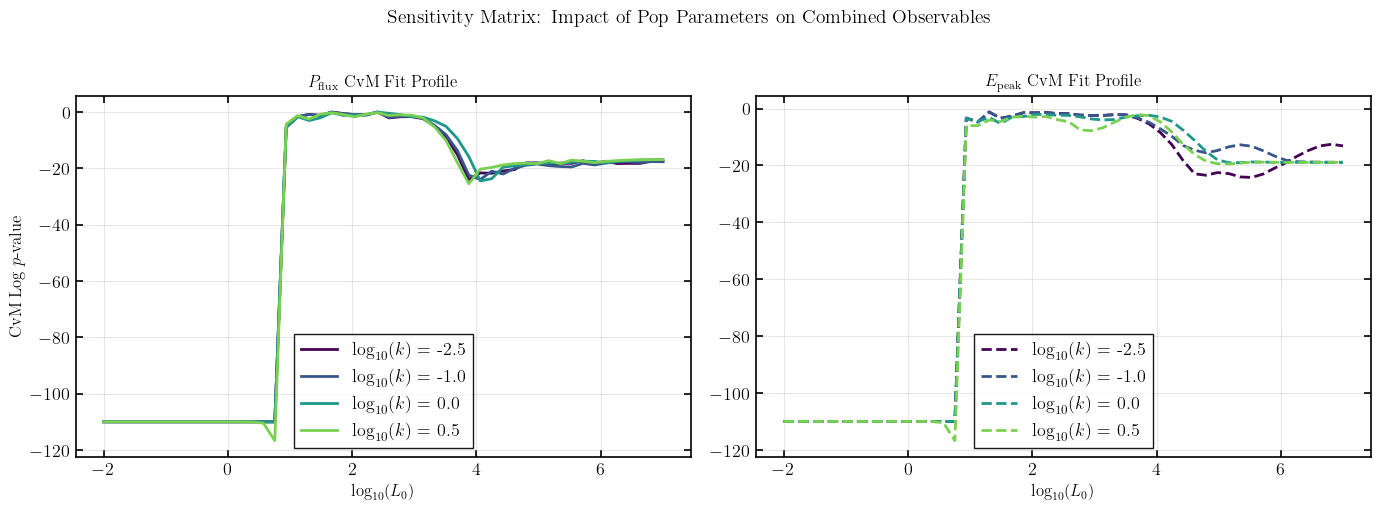

Starting new run from starting point


  0%|          | 0/200000 [00:00<?, ?it/s]/home/ludo/.local/lib/python3.10/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
  7%|▋         | 14241/200000 [12:32<2:35:42, 19.88it/s]/mnt/c/Users/Ludovico/Downloads/MAGGPY/NSBH/Baseline/k_prop_analytical/../../../src/top_hat/montecarlo.py:151: RuntimeWarning: invalid value encountered in log
  return -mu + k * np.log(mu) - sc.gammaln(k + 1)
100%|██████████| 200000/200000 [2:56:47<00:00, 18.85it/s]  


In [37]:
# Run configuration
geom_eff_func = geometric_efficiency_flat_midpoint

# Run the single complete MC chain for all alphas.
run_pop(
    alphas          =   possible_alpha,
    geom_eff_func   =   geom_eff_func,
    datafiles       =   datafiles,
    n_walkers       =   20, 
    n_steps         =   200_000,
    fixed_params    =   fixed_params,
)

Using redshift model: samples_fiducial_delayed_A0.5_BNSs_0.dat with 60187 BNSs.
Computed total merger rate: 60477.4 yr^-1 (local R_0 = 22.7 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 18332.3 yr^-1 (local R_0 = 3.8 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut / A0.5
  BHNSs local rate R_0 = 3.8 Gpc^-3 yr^-1
  BHNSs total rate     = 18332 yr^-1
  1-year z sample size = 18332


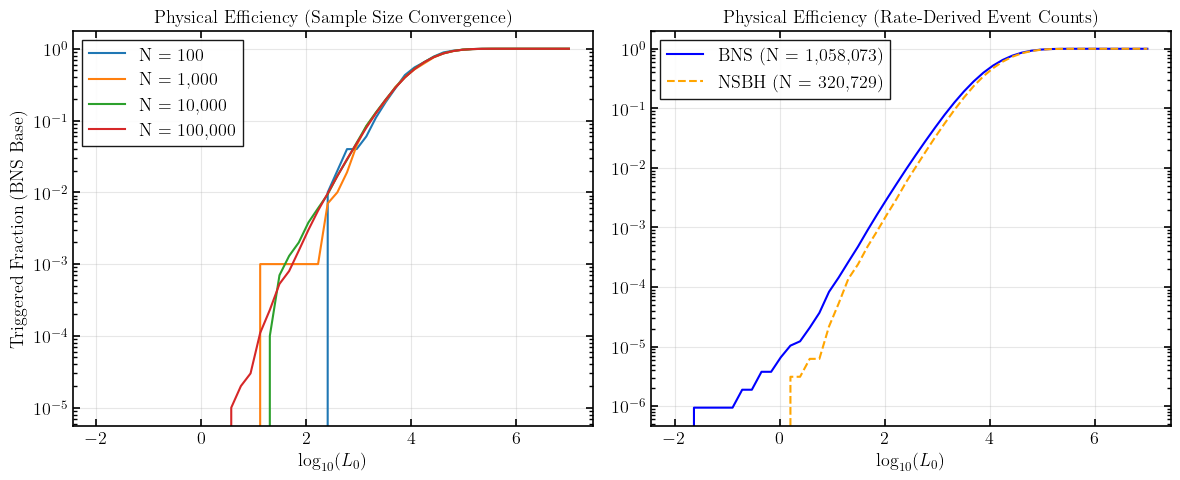

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid as cumtrapz
from scipy.interpolate import interp1d

from src.nsbh.init import initialize_combined_simulation
from src.top_hat.montecarlo import create_k_interpolator, compute_luminosity_distance

def build_redshift_ppf(z_interp_func, z_min=1e-3, z_max=15.0, n_points=1000):
    z_fine = np.linspace(z_min, z_max, n_points)
    dP_dz = z_interp_func(z_fine)
    cdf_fine = cumtrapz(dP_dz, z_fine, initial=0)
    cdf_fine /= cdf_fine[-1]
    return interp1d(
        cdf_fine, 
        z_fine, 
        kind='linear', 
        bounds_error=False, 
        fill_value=(z_min, z_max)
    )

def lognormal_numpy_local(mu, sigma, n, rng):
    l10 = np.log(10)
    return rng.lognormal(mean=mu*l10, sigma=sigma*l10, size=n)

def luminosity_gen_local(A, n, rng):
    shape = (A - 1) / A
    return rng.gamma(shape, size=n) ** (-1 / A)

def generate_realistic_base_flux(
    data_obj, redshift_ppf, k_interpolator, L_mu_E, sigma_E, A_index, n_events
):
    rng = np.random.default_rng(123)
    z_samples = redshift_ppf(rng.uniform(size=n_events))
    d_L = compute_luminosity_distance(z_samples)
    
    E_p_rest = lognormal_numpy_local(L_mu_E, sigma_E, n_events, rng=rng)
    E_p_obs = E_p_rest / (1 + z_samples)
    
    lum_scatter = luminosity_gen_local(A_index, n_events, rng=rng)
    
    pts = np.column_stack((np.log10(E_p_obs), z_samples))
    k_corr = k_interpolator(pts)
    
    return lum_scatter / (4 * np.pi * d_L**2 * k_corr) * 6.242e8

def compute_efficiency_curve(base_flux, L0_grid, pflux_min=4.0):
    efficiencies = np.zeros_like(L0_grid)
    for i, L0 in enumerate(L0_grid):
        scaled_flux = base_flux * 10 ** (L0 + 49)
        efficiencies[i] = np.mean(scaled_flux > pflux_min)
    return efficiencies

def test_realistic_efficiency(alphas, fixed_params, datafiles):
    """Executes both fluctuation and realistic rate tests using your datafiles."""
    
    # Extract the first alpha for validation
    alpha = alphas[0]
    fixed = fixed_params[alpha]
    L_mu_E = fixed["L_mu_E"]
    sigma_E = fixed["sigma_E"]
    A_index = fixed["A_index"]

    demo_params = {"z_model": f"fiducial_delayed_{alpha}"}
    
    bns_params, nsbh_data, _ = initialize_combined_simulation(
        datafiles=datafiles,
        params=demo_params,
        nsbh_population="fiducial_delayed_cut",
        nsbh_alpha=alpha,
    )

    k_interpolator = create_k_interpolator()
    L0_grid = np.linspace(-2, 7, 50)
    
    bns_ppf = build_redshift_ppf(bns_params.P_z_interp)
    nsbh_ppf = build_redshift_ppf(nsbh_data.P_z_interp)

    # Test 1: Fluctuations across different N values
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    event_counts = [100, 1_000, 10_000, 100_000]
    for n in event_counts:
        base_flux = generate_realistic_base_flux(
            bns_params, bns_ppf, k_interpolator, L_mu_E, sigma_E, A_index, n
        )
        eff_curve = compute_efficiency_curve(base_flux, L0_grid)
        plt.plot(L0_grid, eff_curve, label=f"N = {n:,}")

    plt.title("Physical Efficiency (Sample Size Convergence)")
    plt.xlabel(r"$\log_{10}(L_0)$")
    plt.ylabel("Triggered Fraction (BNS Base)")
    plt.legend()
    plt.yscale("log")
    plt.grid(True)

    # Test 2: Rate-derived realistic inputs
    plt.subplot(1, 2, 2)
    bns_events  = int(bns_params.triggered_years * bns_params.total_merger_rate)
    nsbh_events = int(bns_params.triggered_years * nsbh_data.total_merger_rate)

    bns_base_flux   = generate_realistic_base_flux(
        bns_params, bns_ppf, k_interpolator, L_mu_E, sigma_E, A_index, bns_events
    )
    nsbh_base_flux  = generate_realistic_base_flux(
        nsbh_data, nsbh_ppf, k_interpolator, L_mu_E, sigma_E, A_index, nsbh_events
    )

    bns_eff_curve   = compute_efficiency_curve(bns_base_flux, L0_grid)
    nsbh_eff_curve  = compute_efficiency_curve(nsbh_base_flux, L0_grid)

    plt.plot(
        L0_grid, 
        bns_eff_curve, 
        label=f"BNS (N = {bns_events:,})", 
        color="blue"
    )
    plt.plot(
        L0_grid, 
        nsbh_eff_curve, 
        label=f"NSBH (N = {nsbh_events:,})", 
        color="orange", 
        linestyle="dashed"
    )

    plt.title("Physical Efficiency (Rate-Derived Event Counts)")
    plt.xlabel(r"$\log_{10}(L_0)$")
    plt.legend()
    plt.grid(True)
    plt.yscale("log")
    plt.tight_layout()
    plt.show()

test_realistic_efficiency(
    alphas=possible_alpha,
    fixed_params=fixed_params,
    datafiles=datafiles)

Loading existing directory  : Output_files/midpoint_complete_alpha_A0.5


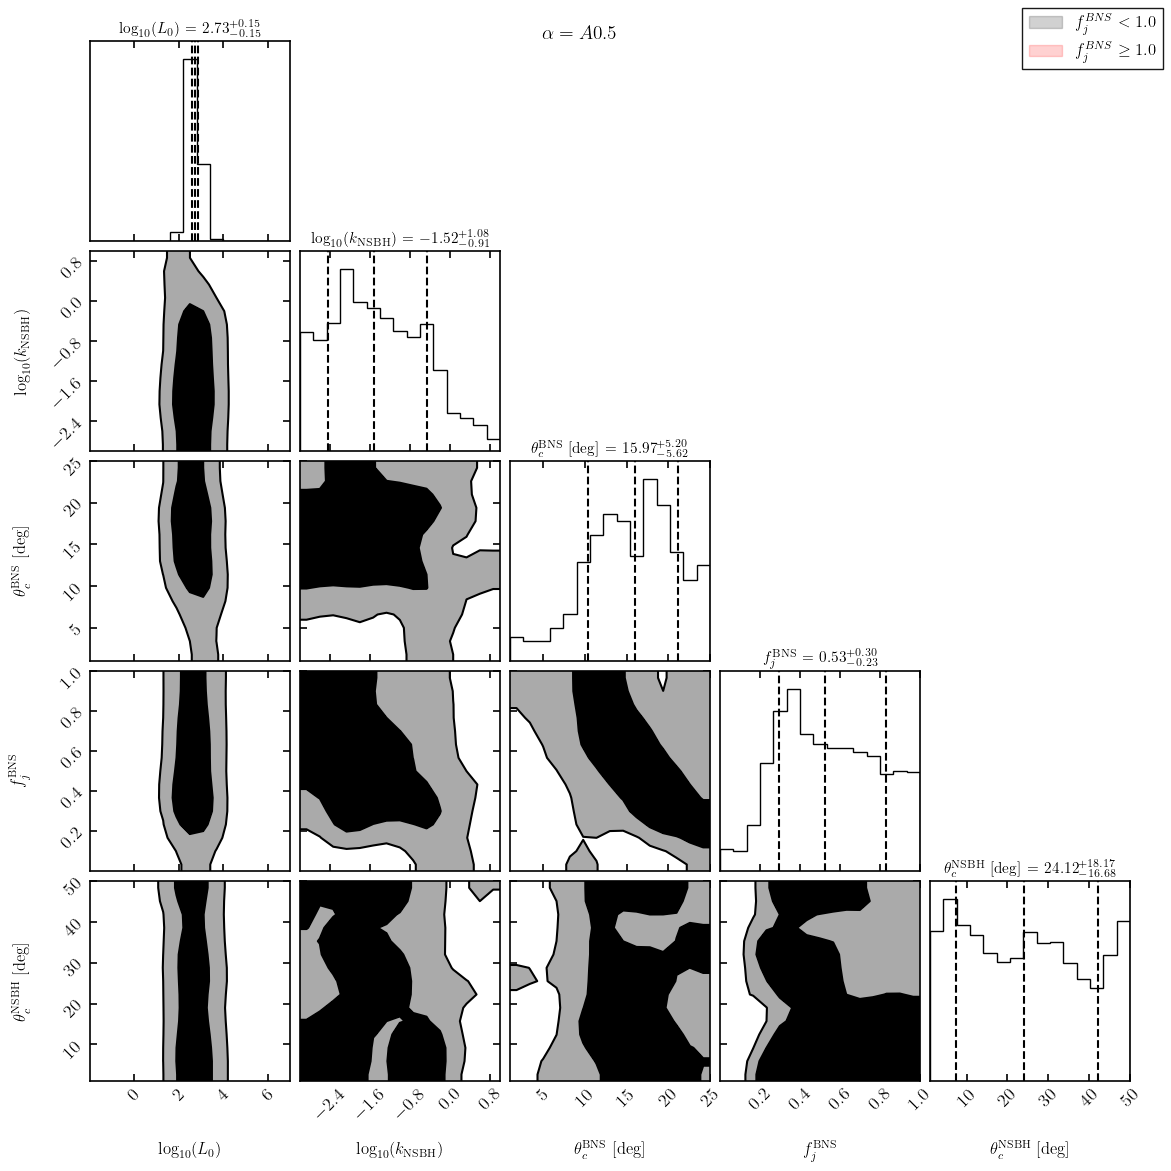

Loading existing directory  : Output_files/midpoint_complete_alpha_A1.0


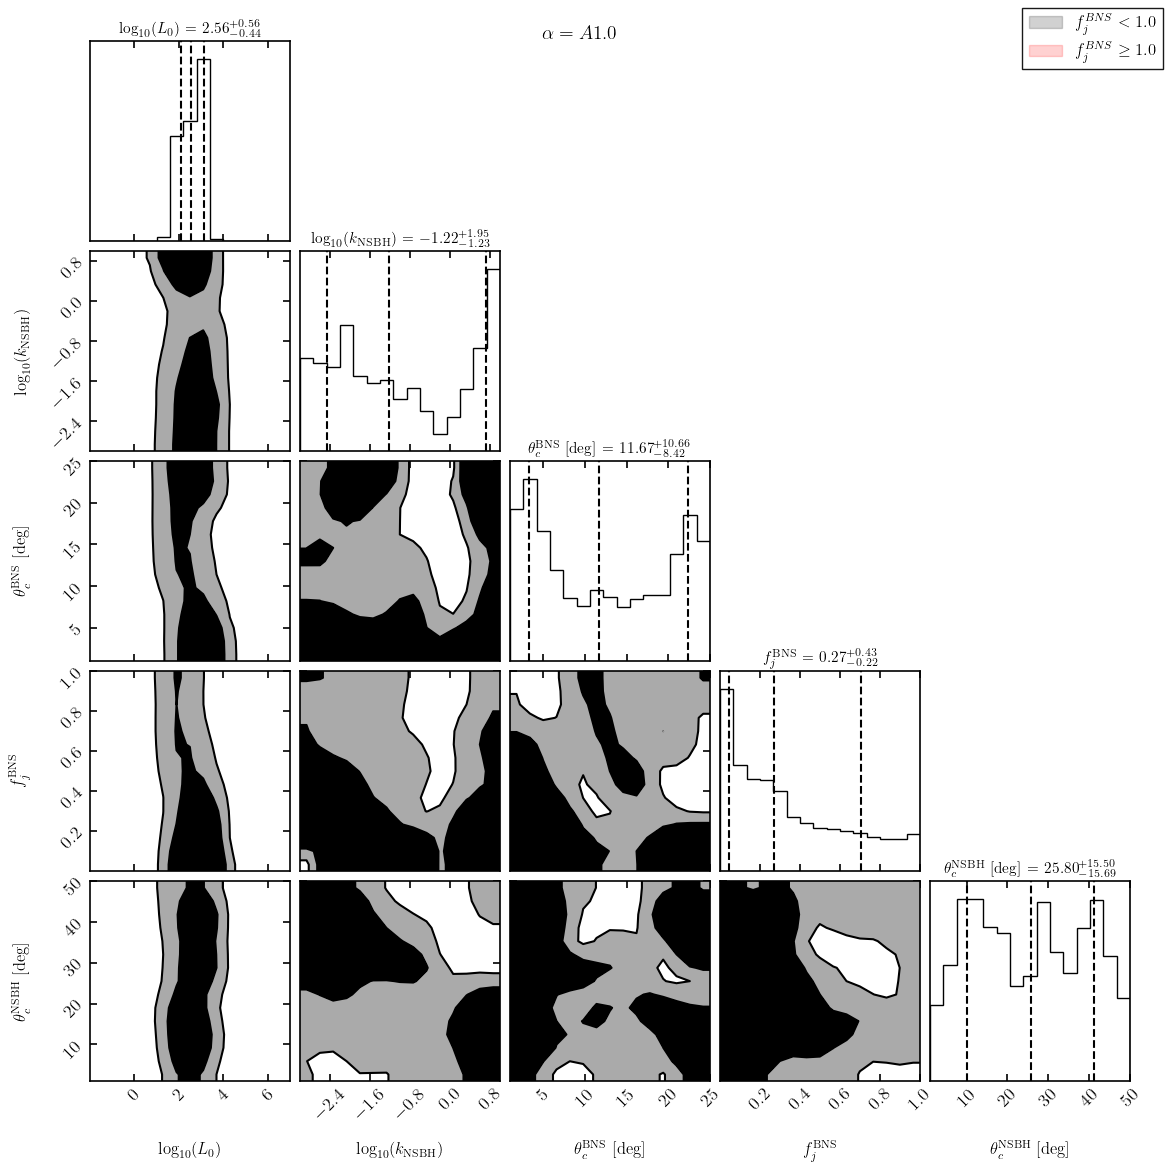

Loading existing directory  : Output_files/midpoint_complete_alpha_A3.0


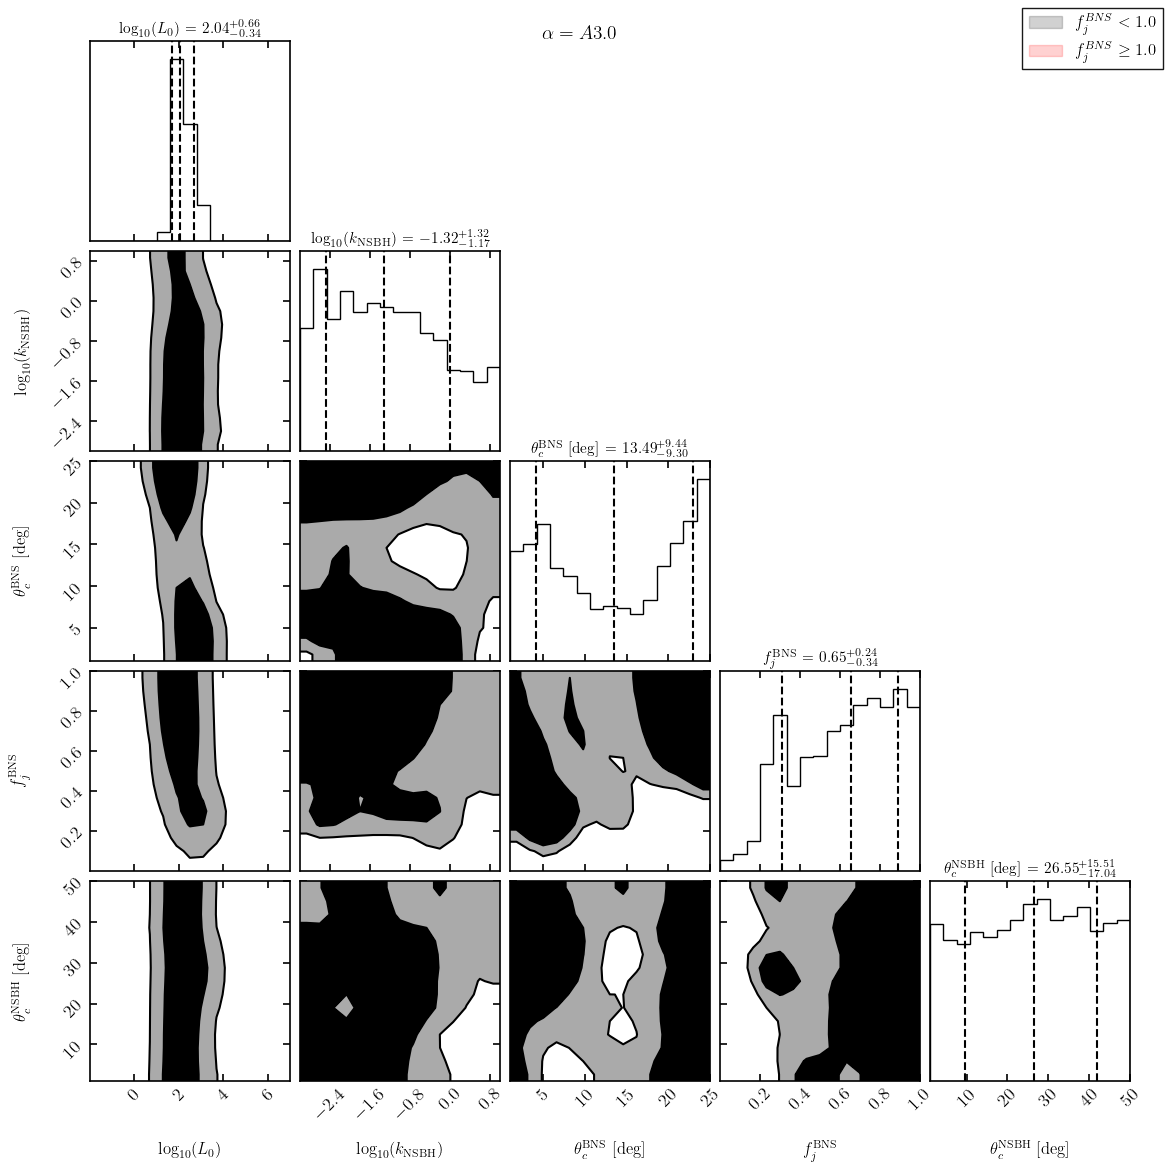

Loading existing directory  : Output_files/midpoint_complete_alpha_A5.0


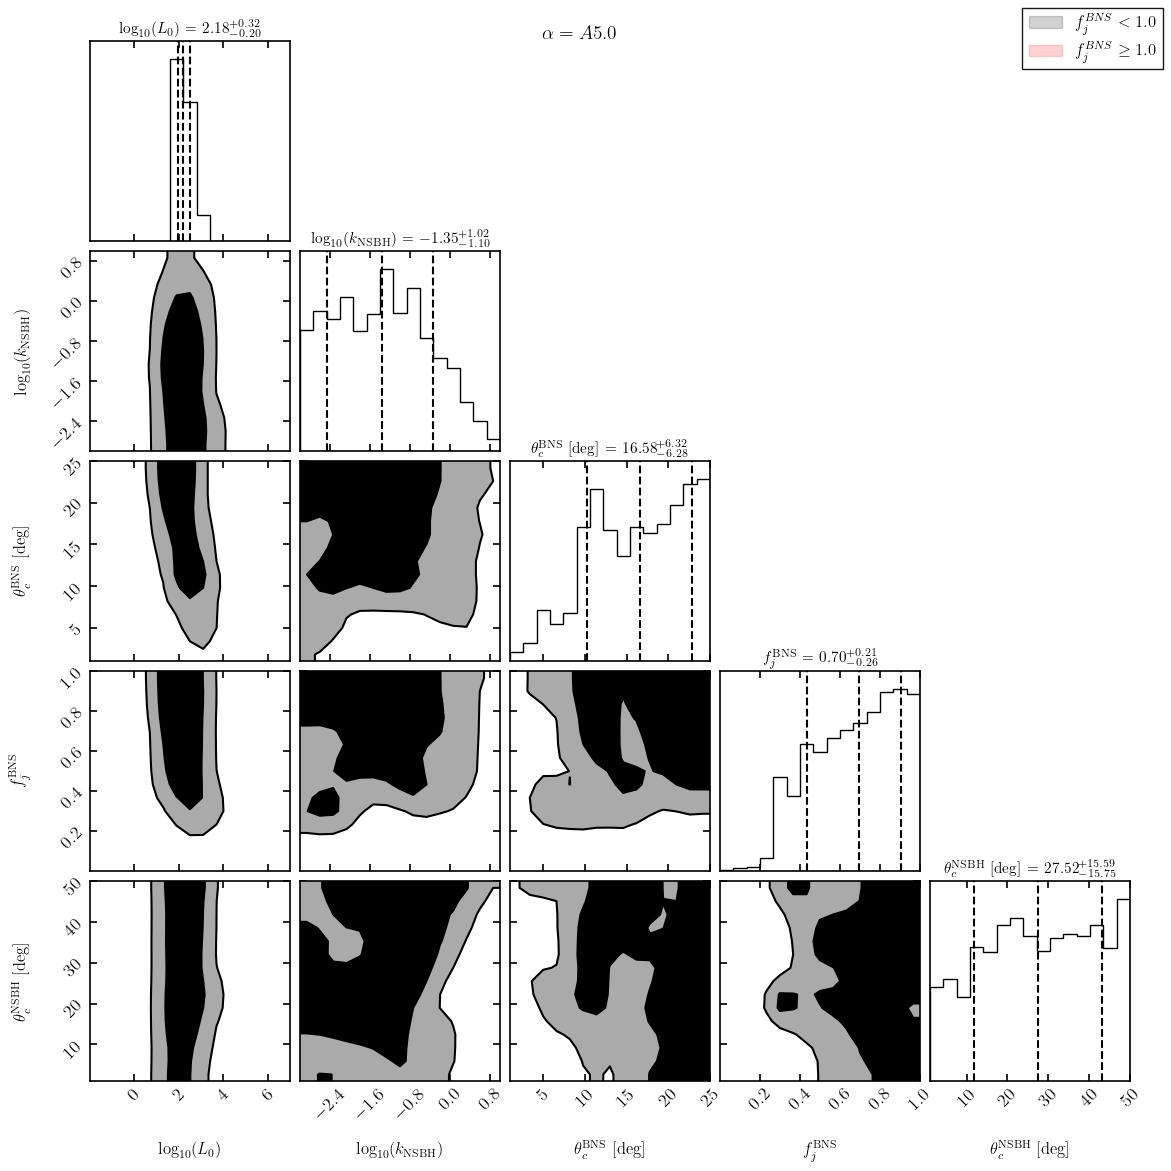

In [43]:
from mcmc_runner import plot_corner_cut

plot_corner_cut(
    alphas=possible_alpha,
    burn_frac=0.3,
    thin=20,
    only_physical = True
)

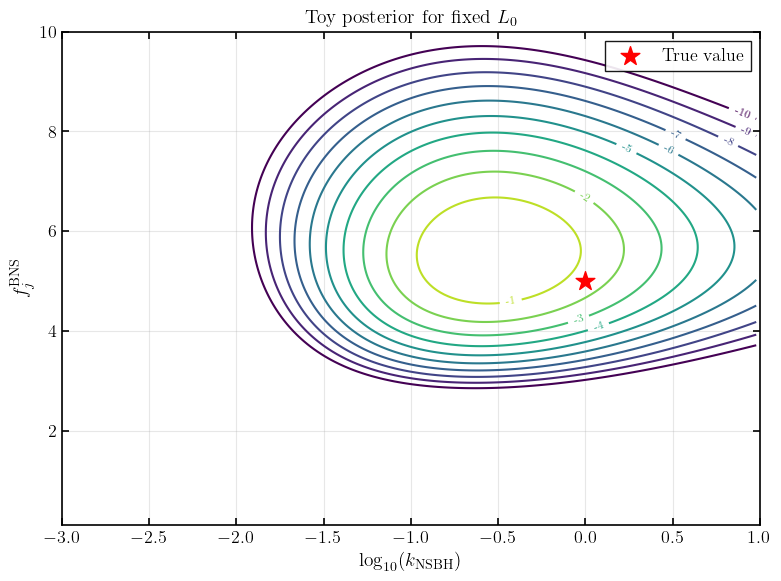

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, norm
from scipy.special import expit  # logistic function

# ------------------------------------------------------------
# Simplified model
# ------------------------------------------------------------
L0_fixed = 3.0                 # log10(L0) fixed at a moderate value
theta_c_bns_fixed = 10.0       # degrees
theta_c_nsbh_fixed = 25.0      # degrees
fj_nsbh_fixed = 5.0            # fixed NSBH beaming factor
R_bns = 100.0                  # intrinsic BNS rate (yr^-1)
R_nsbh = 15.0                  # intrinsic NSBH rate (yr^-1)
T_obs = 10.0                   # observing time (yr)

# Physical detection efficiency: smooth step function of log10(L)
def phys_eff(logL, threshold=2.5, width=1.0):
    """Logistic efficiency: 0 at low L, 1 at high L."""
    return expit((logL - threshold) / width)

# Geometric efficiency (toy: larger theta_c -> larger solid angle -> higher efficiency)
def geom_eff(theta_c):
    """Fraction of sky covered by jet."""
    return 1.0 - np.cos(np.deg2rad(theta_c))  # solid angle factor

# ------------------------------------------------------------
# Simulate "observed" data at some true parameters
# ------------------------------------------------------------
true_k_log = 0.0               # log10(k_nsbh)
true_fj_bns = 5.0

# Compute expected total rate and NSBH fraction
eps_bns_true = phys_eff(L0_fixed) * geom_eff(theta_c_bns_fixed) * true_fj_bns
eps_nsbh_true = phys_eff(L0_fixed + true_k_log) * geom_eff(theta_c_nsbh_fixed) * fj_nsbh_fixed
mu_bns_true = R_bns * T_obs * eps_bns_true
mu_nsbh_true = R_nsbh * T_obs * eps_nsbh_true
mu_tot_true = mu_bns_true + mu_nsbh_true
frac_nsbh_true = mu_nsbh_true / mu_tot_true

# Realisation of the Poisson count and a noisy NSBH fraction (proxy for CvM)
np.random.seed(42)
N_obs = np.random.poisson(mu_tot_true)
# Observed NSBH fraction (mock measurement with some uncertainty)
frac_nsbh_obs = np.random.beta(frac_nsbh_true * 10, (1 - frac_nsbh_true) * 10)  # beta around truth

# ------------------------------------------------------------
# Likelihood function for (k_log, fj_bns)
# ------------------------------------------------------------
def log_likelihood(k_log, fj_bns):
    eps_bns = phys_eff(L0_fixed) * geom_eff(theta_c_bns_fixed) * fj_bns
    eps_nsbh = phys_eff(L0_fixed + k_log) * geom_eff(theta_c_nsbh_fixed) * fj_nsbh_fixed
    mu_bns = R_bns * T_obs * eps_bns
    mu_nsbh = R_nsbh * T_obs * eps_nsbh
    mu_tot = mu_bns + mu_nsbh
    frac = mu_nsbh / mu_tot if mu_tot > 0 else 0.0

    # Poisson log-likelihood for total counts
    ll_pois = poisson.logpmf(N_obs, mu_tot) if mu_tot > 0 else -np.inf

    # Mock CvM term: Gaussian penalty on the NSBH fraction
    # (in reality this comes from comparing full distributions)
    sigma_frac = 0.05  # assumed uncertainty from CvM statistic
    ll_cvm = norm.logpdf(frac, loc=frac_nsbh_obs, scale=sigma_frac)

    return ll_pois + ll_cvm

# Uniform prior on the parameters
def log_prior(k_log, fj_bns):
    if -3 < k_log < 1 and 0 < fj_bns < 10:
        return 0.0
    return -np.inf

def log_posterior(k_log, fj_bns):
    lp = log_prior(k_log, fj_bns)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(k_log, fj_bns)

# ------------------------------------------------------------
# Evaluate on a grid and plot
# ------------------------------------------------------------
k_vals = np.linspace(-3, 1, 200)
fj_vals = np.linspace(0.1, 10, 200)
K, FJ = np.meshgrid(k_vals, fj_vals)
logP = np.zeros_like(K)

for i in range(len(fj_vals)):
    for j in range(len(k_vals)):
        logP[i, j] = log_posterior(K[i, j], FJ[i, j])

# Shift to avoid -inf in contours
logP_max = np.max(logP[np.isfinite(logP)])
logP_plot = logP - logP_max  # log posterior relative to max

# Mask out very low values for cleaner contours
mask = logP_plot < -20
logP_plot = np.ma.array(logP_plot, mask=mask)

plt.figure(figsize=(8, 6))
levels = np.arange(-10, 1, 1)
cont = plt.contour(K, FJ, logP_plot, levels=levels, cmap='viridis')
plt.clabel(cont, inline=True, fontsize=8, fmt='%d')
#plt.scatter([true_k_log], [true_fj_bns], marker='*', color='red', s=200,
#            label='True value', zorder=5)
plt.xlabel(r'$\log_{10}(k_{\rm NSBH})$', fontsize=14)
plt.ylabel(r'$f_j^{\rm BNS}$', fontsize=14)
plt.title('Toy posterior for fixed $L_0$', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('banana_posterior.png', dpi=150)
plt.show()

Plotting autocorrelation for alpha=A0.5


/home/ludo/.local/lib/python3.10/site-packages/emcee/autocorr.py:38: RuntimeWarning: invalid value encountered in divide
  acf /= acf[0]


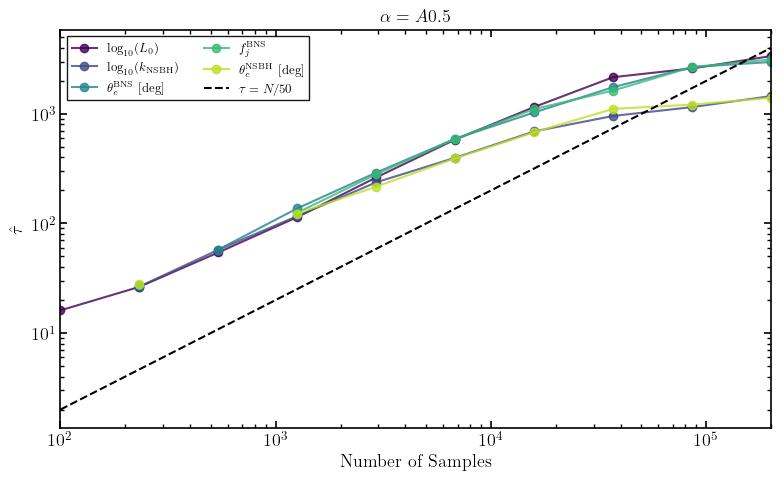

In [40]:
import emcee
from mcmc_runner import labels as param_labels

def plot_alpha_autocorrelation(alpha, backend_path, labels, c=5.0, filename=None, close=True):
    chain = emcee.backends.HDFBackend(backend_path).get_chain()
    n_steps, _, n_params = chain.shape
    n_vals = np.unique(np.clip(np.exp(np.linspace(np.log(100), np.log(n_steps), 10)).astype(int), 100, n_steps))

    fig, ax = plt.subplots(figsize=(8, 5))
    colors = plt.cm.viridis(np.linspace(0, 0.9, n_params))

    for i in range(n_params):
        tau = [np.mean(emcee.autocorr.integrated_time(chain[:n, :, i], c=c, tol=0, quiet=True)) for n in n_vals]
        ax.loglog(n_vals, tau, 'o-', color=colors[i], label=labels[i], alpha=0.8)

    ax.plot(n_vals, n_vals / 50, '--k', lw=1.5, label=r'$\tau = N/50$')
    ax.set(xlabel='Number of Samples', ylabel=r'$\hat{\tau}$', xlim=(100, n_steps))
    ax.set_title(rf'$\alpha = {alpha}$')
    ax.legend(fontsize=9, ncol=2)

    fig.tight_layout()
    if filename is None:
        filename = f'autocorrelation_{alpha}.pdf'
    fig.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    if close:
        plt.close(fig)
    return fig

for alpha in possible_alpha:
    print(f'Plotting autocorrelation for alpha={alpha}')
    # not for baseline but for the new runs, which are more relevant for convergence diagnostics
    path = Path(f"Output_files/midpoint_complete_alpha_{alpha}/emcee.h5")
    plot_alpha_autocorrelation(alpha, path, param_labels)
    break

Using redshift model: samples_fiducial_delayed_A0.5_BNSs_0.dat with 60187 BNSs.
Computed total merger rate: 60477.4 yr^-1 (local R_0 = 22.7 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 18332.3 yr^-1 (local R_0 = 3.8 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut / A0.5
  BHNSs local rate R_0 = 3.8 Gpc^-3 yr^-1
  BHNSs total rate     = 18332 yr^-1
  1-year z sample size = 18332
Loading existing directory  : Output_files/midpoint_complete_alpha_A0.5


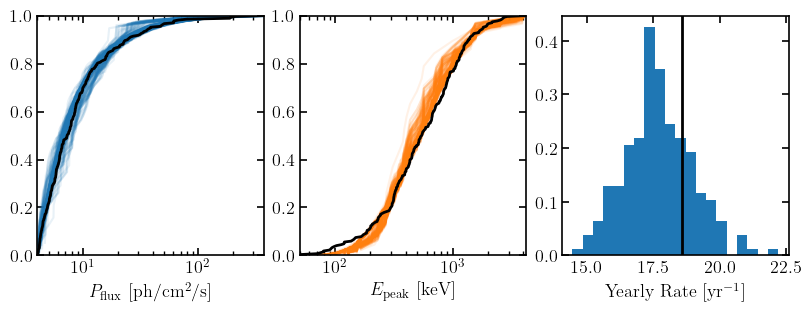

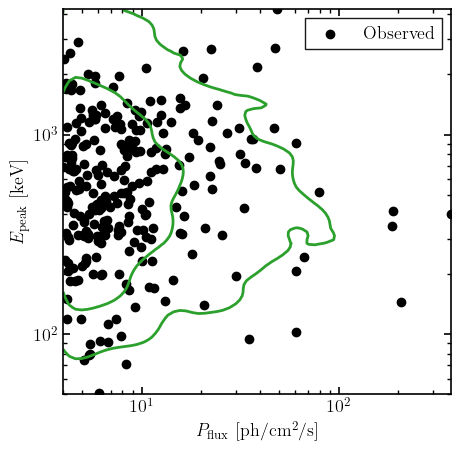

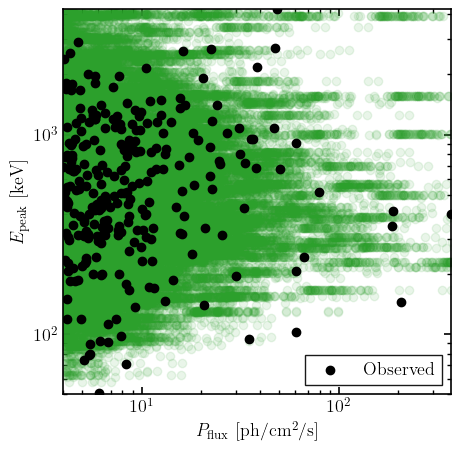

(<Figure size 500x500 with 1 Axes>,
 <Axes: xlabel='$P_{\\mathrm{flux}}$ [ph/cm$^2$/s]', ylabel='$E_{\\mathrm{peak}}$ [keV]'>)

In [45]:
from mcmc_runner import _load_chain, setup_forward_ppc, plot_ppc

alpha_cdf = possible_alpha[0]
forward_model_ppc, observed = setup_forward_ppc(
    alpha=alpha_cdf,
    geom_eff_func=geom_eff_func,
    fixed_params=fixed_params,
)

_, flat, _ = _load_chain(alpha_cdf, burn_frac=0.3, thin=20)

idx = np.random.default_rng(1234).choice(
    len(flat),
    size=200,
    replace=False,
)

theta_draws = flat[idx]
plot_ppc(
    theta_draws,
    forward_model_ppc,
    observed,
)